# NB06: Annotation Source Resolution

NB01–NB05 showed *that* annotation sources differ. This notebook answers the practical question: **given a gene, which annotation should you trust?**

**Key questions:**
1. What evidence does the agent actually use, and how does it differ from RAST/Bakta?
2. When we use Bakta as an independent adjudicator, which source does it favor?
3. Can we build a per-gene decision framework for choosing the best annotation source?

**Key outputs:**
- Per-gene best-source recommendation
- `data/annotation_recommendations.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if 'adp1_annotation_reassessment' not in PROJECT_DIR:
    PROJECT_DIR = 'projects/adp1_annotation_reassessment'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

master = pd.read_csv(os.path.join(PROJECT_DIR, 'data/master_annotation_table.csv'))
protein = master[master['sequence'].notna()].copy()
print(f'Master table: {len(master)} features ({len(protein)} protein-coding)')

Master table: 5852 features (3209 protein-coding)


## Part 1: What the Agent Actually Does Differently

The agent uses GPT-5.2 to reason over InterProScan domain matches, sequence homology to characterized genes, gene neighborhood conservation, and RB-TnSeq fitness data from homologs in other Fitness Browser organisms. We classify evidence types across **all** 3,003 agent-annotated genes (not just the 120 unique ones from NB05).

In [2]:
has_agent = protein[protein['agent_class'] != 'missing'].copy()
n_annotated = len(has_agent)
print(f'Agent-annotated protein-coding genes: {n_annotated}')

def classify_evidence(evidence):
    """Classify evidence types used by the agent."""
    if pd.isna(evidence) or evidence == '':
        return {'domain': False, 'homology': False, 'neighborhood': False,
                'fitness': False, 'experimental': False, 'papers': False}
    e = str(evidence)
    return {
        'domain': bool(re.search(r'InterPro|IPR\d|Pfam|PF\d|TIGRFAM|TIGR\d|InterProScan|domain', e, re.IGNORECASE)),
        'homology': bool(re.search(r'identity|identical|homolog|sequence similarity|ortholog', e, re.IGNORECASE)),
        'neighborhood': bool(re.search(r'gene neighborhood|colocated|synteny|operon|adjacent|genomic context', e, re.IGNORECASE)),
        'fitness': bool(re.search(r'fitness|phenotype|growth defect|essentiality|mutant|RB-TnSeq', e, re.IGNORECASE)),
        'experimental': bool(re.search(r'experiment|characterized|demonstrated|crystal structure|biochemical', e, re.IGNORECASE)),
        'papers': bool(re.search(r'PMID|doi:|10\.\d{4}|published|paper|journal', e, re.IGNORECASE)),
    }

ev_df = has_agent['agent_evidence'].apply(classify_evidence).apply(pd.Series)
has_agent = pd.concat([has_agent.reset_index(drop=True), ev_df.reset_index(drop=True)], axis=1)

print(f'\nEvidence types across {n_annotated} agent-annotated genes:')
evidence_counts = {}
for col in ['domain', 'homology', 'neighborhood', 'fitness', 'experimental', 'papers']:
    n = has_agent[col].sum()
    pct = n / n_annotated * 100
    evidence_counts[col] = n
    print(f'  {col:15s}: {n:5d} ({pct:.1f}%)')

# Check reasoning field for paper citations
papers_in_reasoning = has_agent['agent_reasoning'].str.contains(r'PMID|doi:|10\.\d{4}', na=False, regex=True).sum()
print(f'\n  Papers in reasoning field: {papers_in_reasoning}')
print(f'\nThe agent\'s value is NOT from literature access — it\'s from:')
print(f'  (a) reasoning over domain combinations ({evidence_counts["domain"]} genes)')
print(f'  (b) incorporating fitness data from homologs ({evidence_counts["fitness"]} genes)')

Agent-annotated protein-coding genes: 3003



Evidence types across 3003 agent-annotated genes:
  domain         :  2759 (91.9%)
  homology       :  1975 (65.8%)
  neighborhood   :  1181 (39.3%)
  fitness        :  2244 (74.7%)
  experimental   :   170 (5.7%)
  papers         :     5 (0.2%)

  Papers in reasoning field: 0

The agent's value is NOT from literature access — it's from:
  (a) reasoning over domain combinations (2759 genes)
  (b) incorporating fitness data from homologs (2244 genes)


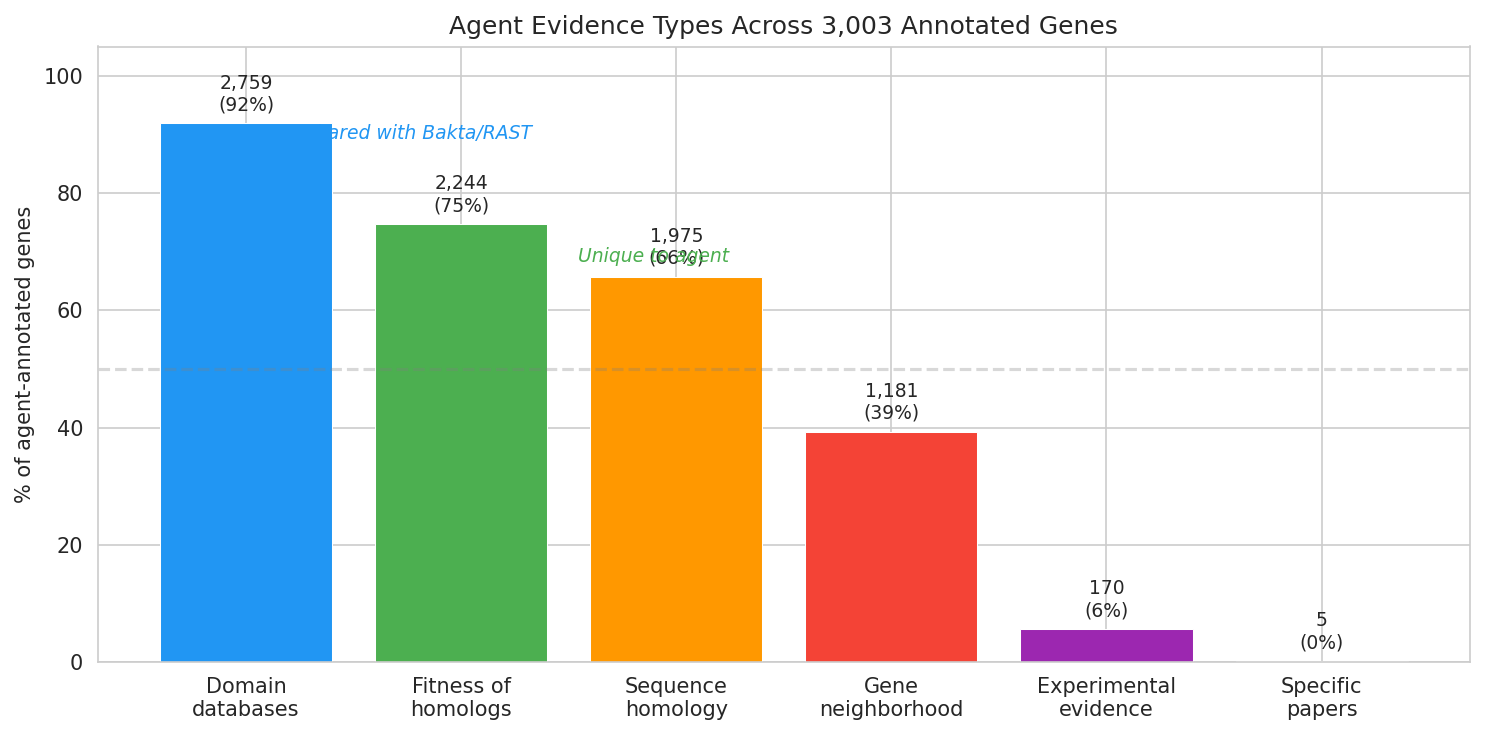

In [3]:
# Visualize evidence type distribution
ev_labels = ['Domain\ndatabases', 'Fitness of\nhomologs', 'Sequence\nhomology',
             'Gene\nneighborhood', 'Experimental\nevidence', 'Specific\npapers']
ev_cols = ['domain', 'fitness', 'homology', 'neighborhood', 'experimental', 'papers']
ev_vals = [has_agent[c].sum() for c in ev_cols]
ev_pcts = [v / n_annotated * 100 for v in ev_vals]

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0', '#607D8B']
bars = ax.bar(ev_labels, ev_pcts, color=colors, edgecolor='white', linewidth=0.5)
for bar, val, pct in zip(bars, ev_vals, ev_pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{val:,}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('% of agent-annotated genes')
ax.set_title(f'Agent Evidence Types Across {n_annotated:,} Annotated Genes')
ax.set_ylim(0, 105)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.3)

# Add annotation: shared vs unique to agent
ax.annotate('Shared with Bakta/RAST', xy=(0.15, 0.85), xycoords='axes fraction',
            fontsize=9, color='#2196F3', fontstyle='italic')
ax.annotate('Unique to agent', xy=(0.35, 0.65), xycoords='axes fraction',
            fontsize=9, color='#4CAF50', fontstyle='italic')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/source_resolution.png'), dpi=150, bbox_inches='tight')
plt.show()

## Part 2: Using Bakta as Independent Adjudicator

When RAST and the agent disagree, we use Bakta as a tiebreaker. Bakta is a good adjudicator because it uses an independent annotation pipeline (alignment-free sequence identification against UniProt, Pfam, COG) with a short, function-name annotation style similar to RAST.

We compute TF-IDF cosine similarity of each source's annotation against Bakta's, then check which source Bakta agrees with more — broken down by RAST annotation category.

In [4]:
# Categorize RAST annotation quality
def rast_category(ann):
    """Classify RAST annotations by informativeness."""
    if pd.isna(ann) or str(ann).strip() == '':
        return 'missing'
    a = str(ann).strip()
    al = a.lower()
    # Hypothetical
    if re.match(r'^(hypothetical|uncharacterized|predicted protein|conserved hypothetical)', al):
        return 'hypothetical'
    # Uninformative: generic descriptions
    if re.match(r'^(putative (membrane|cytoplasmic|inner membrane|outer membrane) protein$|'
                r'membrane protein$|protein of unknown|possible )', al):
        return 'uninformative'
    # Has enzyme indicators
    if re.search(r'EC \d|\d\.\d+\.\d+\.\d+|synthase|kinase|dehydrogenase|reductase|'
                 r'transferase|lyase|ligase|isomerase|oxidase|hydrolase|protease|peptidase|'
                 r'esterase|aldolase|carboxylase|mutase|racemase|epimerase', al):
        return 'enzyme'
    # Regulator
    if re.search(r'regulator|repressor|activator|transcription', al):
        return 'regulator'
    # Transporter
    if re.search(r'transport|permease|porin|channel|pump|efflux|symport|antiport|\bABC\b', al):
        return 'transporter'
    return 'other_specific'

protein['rast_category'] = protein['rast_function'].apply(rast_category)
print('RAST annotation categories (protein-coding):')
print(protein['rast_category'].value_counts().to_string())

RAST annotation categories (protein-coding):
rast_category
enzyme            1266
other_specific    1011
hypothetical       403
transporter        297
regulator          190
uninformative       42


In [5]:
# Bakta adjudication: for genes where all three sources provide specific annotations,
# compute TF-IDF similarity of agent and RAST against Bakta
triple_specific = protein[
    (protein['rast_class'] == 'specific') &
    (protein['bakta_class'] == 'specific') &
    (protein['agent_class'] == 'specific')
].copy()
print(f'Genes with all three sources specific: {len(triple_specific)}')

# Fit TF-IDF on all annotations
all_texts = pd.concat([
    triple_specific['bakta_function'],
    triple_specific['agent_annotation'],
    triple_specific['rast_function']
]).astype(str)
tfidf = TfidfVectorizer(token_pattern=r'[a-zA-Z]{3,}', lowercase=True)
tfidf.fit(all_texts)

bakta_vecs = tfidf.transform(triple_specific['bakta_function'].astype(str))
agent_vecs = tfidf.transform(triple_specific['agent_annotation'].astype(str))
rast_vecs = tfidf.transform(triple_specific['rast_function'].astype(str))

# Pairwise cosine similarity (each gene independently)
ba_sim = np.array([cosine_similarity(bakta_vecs[i], agent_vecs[i])[0, 0] for i in range(len(triple_specific))])
br_sim = np.array([cosine_similarity(bakta_vecs[i], rast_vecs[i])[0, 0] for i in range(len(triple_specific))])

triple_specific['bakta_agent_sim'] = ba_sim
triple_specific['bakta_rast_sim'] = br_sim
triple_specific['bakta_prefers'] = np.where(
    ba_sim > br_sim, 'agent',
    np.where(br_sim > ba_sim, 'RAST', 'tie')
)

print(f'\nBakta adjudication (TF-IDF cosine):')
print(triple_specific['bakta_prefers'].value_counts().to_string())

non_tie = triple_specific[triple_specific['bakta_prefers'] != 'tie']
agent_wins = (non_tie['bakta_prefers'] == 'agent').sum()
rast_wins = (non_tie['bakta_prefers'] == 'RAST').sum()
print(f'\nAgent wins {agent_wins} vs RAST wins {rast_wins} (agent win rate: {agent_wins/(agent_wins+rast_wins)*100:.1f}%)')
print(f'\nNote: RAST and Bakta share similar short annotation styles, so TF-IDF naturally')
print(f'favors RAST. The breakdown by RAST category (below) reveals where the agent truly adds value.')

Genes with all three sources specific: 2682



Bakta adjudication (TF-IDF cosine):
bakta_prefers
RAST     1808
agent     727
tie       147

Agent wins 727 vs RAST wins 1808 (agent win rate: 28.7%)

Note: RAST and Bakta share similar short annotation styles, so TF-IDF naturally
favors RAST. The breakdown by RAST category (below) reveals where the agent truly adds value.


In [6]:
# Breakdown by RAST category
triple_specific['rast_category'] = triple_specific['rast_function'].apply(rast_category)

print('Bakta adjudication by RAST annotation category:')
print(f'{"Category":20s} {"N":>5s} {"Agent":>6s} {"RAST":>6s} {"Tie":>5s} {"Agent %":>8s}')
print('-' * 55)

category_results = []
for cat in ['uninformative', 'hypothetical', 'enzyme', 'regulator', 'transporter', 'other_specific']:
    subset = triple_specific[triple_specific['rast_category'] == cat]
    if len(subset) == 0:
        continue
    n_agent = (subset['bakta_prefers'] == 'agent').sum()
    n_rast = (subset['bakta_prefers'] == 'RAST').sum()
    n_tie = (subset['bakta_prefers'] == 'tie').sum()
    non_tie_n = n_agent + n_rast
    win_pct = n_agent / non_tie_n * 100 if non_tie_n > 0 else 0
    print(f'{cat:20s} {len(subset):5d} {n_agent:6d} {n_rast:6d} {n_tie:5d} {win_pct:7.1f}%')
    category_results.append({'category': cat, 'n': len(subset), 'agent': n_agent, 'rast': n_rast, 'tie': n_tie, 'agent_pct': win_pct})

cat_df = pd.DataFrame(category_results)

Bakta adjudication by RAST annotation category:
Category                 N  Agent   RAST   Tie  Agent %
-------------------------------------------------------
uninformative           21     10      6     5    62.5%
hypothetical            52     26     23     3    53.1%
enzyme                1251    288    900    63    24.2%
regulator              189     33    153     3    17.7%
transporter            294    101    182    11    35.7%
other_specific         875    269    544    62    33.1%


In [7]:
# Neighborhood evidence effect on Bakta agreement
ev_cols_for_triple = has_agent[has_agent.index.isin(triple_specific.index)][['neighborhood']]
# Re-classify evidence for triple_specific
triple_ev = triple_specific['agent_evidence'].apply(classify_evidence).apply(pd.Series)
triple_specific = pd.concat([triple_specific.reset_index(drop=True), triple_ev.reset_index(drop=True)], axis=1)

with_n = triple_specific[triple_specific['neighborhood']]
without_n = triple_specific[~triple_specific['neighborhood']]

print('Effect of gene neighborhood evidence on Bakta agreement:')
print(f'\n  With neighborhood ({len(with_n)} genes):')
print(f'    Mean Bakta-agent similarity: {with_n["bakta_agent_sim"].mean():.3f}')
print(f'    Mean Bakta-RAST similarity:  {with_n["bakta_rast_sim"].mean():.3f}')
n_agent_n = (with_n['bakta_prefers'] == 'agent').sum()
n_rast_n = (with_n['bakta_prefers'] == 'RAST').sum()
print(f'    Agent win rate: {n_agent_n}/{n_agent_n+n_rast_n} = {n_agent_n/(n_agent_n+n_rast_n)*100:.1f}%')

print(f'\n  Without neighborhood ({len(without_n)} genes):')
print(f'    Mean Bakta-agent similarity: {without_n["bakta_agent_sim"].mean():.3f}')
print(f'    Mean Bakta-RAST similarity:  {without_n["bakta_rast_sim"].mean():.3f}')
n_agent_wn = (without_n['bakta_prefers'] == 'agent').sum()
n_rast_wn = (without_n['bakta_prefers'] == 'RAST').sum()
print(f'    Agent win rate: {n_agent_wn}/{n_agent_wn+n_rast_wn} = {n_agent_wn/(n_agent_wn+n_rast_wn)*100:.1f}%')

print(f'\nGene neighborhood evidence is associated with LOWER Bakta agreement — the agent')
print(f'tends to fabricate functional claims based on genomic context in other organisms.')

Effect of gene neighborhood evidence on Bakta agreement:

  With neighborhood (942 genes):
    Mean Bakta-agent similarity: 0.202
    Mean Bakta-RAST similarity:  0.492
    Agent win rate: 213/868 = 24.5%

  Without neighborhood (1740 genes):
    Mean Bakta-agent similarity: 0.347
    Mean Bakta-RAST similarity:  0.536
    Agent win rate: 514/1667 = 30.8%

Gene neighborhood evidence is associated with LOWER Bakta agreement — the agent
tends to fabricate functional claims based on genomic context in other organisms.


## Part 3: Decision Framework

Based on the evidence analysis and adjudication results, we assign each protein-coding gene a `best_source` recommendation:

| Category | Rule | Rationale |
|----------|------|-----------|
| **Consensus** | All sources agree (high TF-IDF similarity) | No conflict to resolve |
| **RAST** | RAST has specific annotation; agent uses only gene neighborhood or weak evidence | RAST's curated subsystems are reliable for well-characterized functions |
| **Agent** | RAST is hypothetical/uninformative; agent has domain-based or fitness-supported evidence | Agent adds value through domain interpretation |
| **Bakta** | Both RAST and agent are hypothetical; Bakta has domain/family annotation | Bakta's conservative family-level annotation is accurate |
| **Needs review** | Agent gives specific annotation but evidence is weak (no domains, neighborhood-only) or contradicted | High over-specification risk |

In [8]:
# Classify evidence for ALL protein-coding genes with agent annotation
ev_all = protein['agent_evidence'].apply(classify_evidence).apply(pd.Series)
protein = pd.concat([protein.reset_index(drop=True), ev_all.reset_index(drop=True)], axis=1)

def assign_best_source(row):
    """Assign the best annotation source for each gene."""
    rast = row['rast_class']
    bakta = row['bakta_class']
    agent = row['agent_class']
    rast_cat = row.get('rast_category', 'missing')
    has_domain = row.get('domain', False)
    has_fitness_ev = row.get('fitness', False)
    has_neighborhood = row.get('neighborhood', False)
    has_homology = row.get('homology', False)
    
    # No agent annotation: use RAST or Bakta
    if agent == 'missing':
        if rast == 'specific':
            return 'RAST'
        if bakta == 'specific':
            return 'Bakta'
        return 'None available'
    
    # All hypothetical: no good source
    if rast != 'specific' and bakta != 'specific' and agent != 'specific':
        return 'None available'
    
    # Agent specific, RAST hypothetical/missing
    if rast != 'specific' and agent == 'specific':
        if bakta == 'specific':
            # Both agent and Bakta have annotations — prefer Bakta for conservative naming
            # but agent adds value if it has domain+fitness evidence
            if has_domain and has_fitness_ev:
                return 'Agent'
            return 'Bakta'
        else:
            # Only agent has annotation
            if has_domain:
                return 'Agent'
            if has_neighborhood and not has_homology:
                return 'Needs review'
            return 'Agent'
    
    # RAST specific, agent specific
    if rast == 'specific' and agent == 'specific':
        # RAST uninformative → prefer agent
        if rast_cat == 'uninformative':
            if has_domain:
                return 'Agent'
            return 'Needs review'
        # RAST has good annotation
        # Agent neighborhood-only evidence → prefer RAST
        if has_neighborhood and not has_domain and not has_fitness_ev:
            return 'RAST'
        # Default: RAST for well-characterized functions
        return 'RAST'
    
    # RAST specific, agent hypothetical/missing
    if rast == 'specific':
        return 'RAST'
    
    # Bakta specific, others not
    if bakta == 'specific':
        return 'Bakta'
    
    return 'None available'

protein['best_source'] = protein.apply(assign_best_source, axis=1)

print('Best source recommendations:')
print(protein['best_source'].value_counts().to_string())
print(f'\nTotal protein-coding: {len(protein)}')

Best source recommendations:
best_source
RAST              2756
Agent              191
Bakta              161
None available      89
Needs review        12

Total protein-coding: 3209


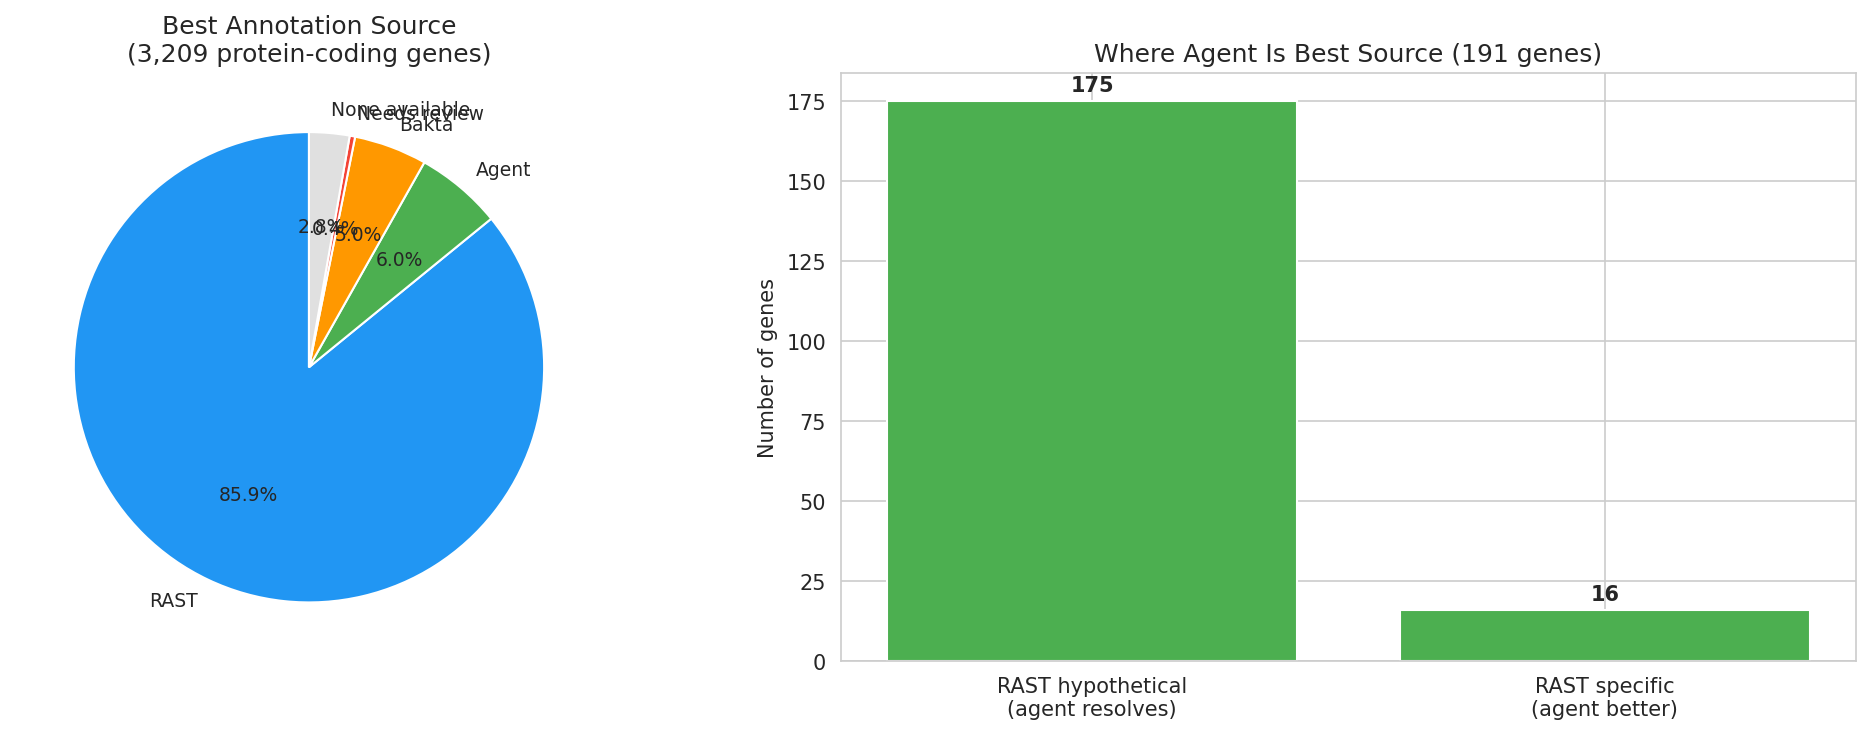

In [9]:
# Visualize decision framework results
source_counts = protein['best_source'].value_counts()
source_order = ['RAST', 'Agent', 'Bakta', 'Needs review', 'None available']
source_counts = source_counts.reindex(source_order).fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: pie chart of best source
colors_map = {'RAST': '#2196F3', 'Agent': '#4CAF50', 'Bakta': '#FF9800',
              'Needs review': '#F44336', 'None available': '#E0E0E0'}
pie_colors = [colors_map[s] for s in source_order]
wedges, texts, autotexts = axes[0].pie(
    source_counts.values, labels=source_counts.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=90, textprops={'fontsize': 9}
)
axes[0].set_title(f'Best Annotation Source\n({len(protein):,} protein-coding genes)')

# Right: breakdown of where agent adds value
agent_genes = protein[protein['best_source'] == 'Agent']
agent_by_rast = agent_genes['rast_class'].value_counts()
agent_labels = ['RAST hypothetical\n(agent resolves)', 'RAST missing\n(agent-only)', 'RAST specific\n(agent better)']
agent_vals = [
    agent_by_rast.get('hypothetical', 0),
    agent_by_rast.get('missing', 0),
    agent_by_rast.get('specific', 0)
]
# Only show non-zero
mask = [v > 0 for v in agent_vals]
agent_labels = [l for l, m in zip(agent_labels, mask) if m]
agent_vals = [v for v, m in zip(agent_vals, mask) if m]

bars = axes[1].bar(agent_labels, agent_vals, color='#4CAF50', edgecolor='white')
for bar, val in zip(bars, agent_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Number of genes')
axes[1].set_title(f'Where Agent Is Best Source ({len(agent_genes)} genes)')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/source_resolution.png'), dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Validate: score decision framework against condition-specific concordance
# Load condition-specific genes from sibling project
cond_path = os.path.join(PROJECT_DIR, '../adp1_deletion_phenotypes/data/condition_specific_genes.csv')
if os.path.exists(cond_path):
    cond_genes = pd.read_csv(cond_path)
    print(f'Condition-specific genes: {len(cond_genes)}')
    
    # Merge with protein to get best_source
    # Match on feature_id or old_locus_tag
    merge_col = 'locusId' if 'locusId' in cond_genes.columns else 'feature_id'
    if merge_col == 'locusId':
        cond_merged = cond_genes.merge(protein[['feature_id', 'best_source', 'rast_function', 'bakta_function', 'agent_annotation', 'rast_class', 'bakta_class', 'agent_class']],
                                        left_on='locusId', right_on='feature_id', how='inner')
    else:
        cond_merged = cond_genes.merge(protein[['feature_id', 'best_source', 'rast_function', 'bakta_function', 'agent_annotation', 'rast_class', 'bakta_class', 'agent_class']],
                                        on='feature_id', how='inner')
    print(f'Matched: {len(cond_merged)}')
    
    # How many condition-specific genes have a specific annotation from their best source?
    def has_specific_from_best(row):
        src = row['best_source']
        if src == 'RAST':
            return row['rast_class'] == 'specific'
        elif src == 'Agent':
            return row['agent_class'] == 'specific'
        elif src == 'Bakta':
            return row['bakta_class'] == 'specific'
        return False
    
    cond_merged['best_has_specific'] = cond_merged.apply(has_specific_from_best, axis=1)
    
    # Compare: best_source specific rate vs individual sources
    print(f'\nCondition-specific genes with specific annotation:')
    print(f'  Best source: {cond_merged["best_has_specific"].sum()}/{len(cond_merged)} ({cond_merged["best_has_specific"].mean()*100:.1f}%)')
    print(f'  RAST alone:  {(cond_merged["rast_class"] == "specific").sum()}/{len(cond_merged)} ({(cond_merged["rast_class"] == "specific").mean()*100:.1f}%)')
    print(f'  Agent alone: {(cond_merged["agent_class"] == "specific").sum()}/{len(cond_merged)} ({(cond_merged["agent_class"] == "specific").mean()*100:.1f}%)')
    print(f'  Bakta alone: {(cond_merged["bakta_class"] == "specific").sum()}/{len(cond_merged)} ({(cond_merged["bakta_class"] == "specific").mean()*100:.1f}%)')
else:
    print(f'Condition-specific genes file not found: {cond_path}')
    print('Skipping concordance validation.')

Condition-specific genes: 2034
Matched: 2007

Condition-specific genes with specific annotation:
  Best source: 1938/2007 (96.6%)
  RAST alone:  1725/2007 (85.9%)
  Agent alone: 1848/2007 (92.1%)
  Bakta alone: 1827/2007 (91.0%)


In [11]:
# Validate: respiratory chain accuracy
resp_path = os.path.join(PROJECT_DIR, '../respiratory_chain_wiring/data/respiratory_chain_genes.csv')
if os.path.exists(resp_path):
    resp_genes = pd.read_csv(resp_path)
    print(f'Respiratory chain genes: {len(resp_genes)}')
    
    # Match on feature_id
    merge_col = 'locusId' if 'locusId' in resp_genes.columns else 'feature_id'
    if merge_col == 'locusId':
        resp_merged = resp_genes.merge(
            protein[['feature_id', 'best_source', 'rast_function', 'bakta_function', 'agent_annotation']],
            left_on='locusId', right_on='feature_id', how='inner'
        )
    else:
        resp_merged = resp_genes.merge(
            protein[['feature_id', 'best_source', 'rast_function', 'bakta_function', 'agent_annotation']],
            on='feature_id', how='inner'
        )
    print(f'Matched: {len(resp_merged)}')
    
    # For respiratory chain, check if best-source annotation contains relevant keywords
    resp_keywords = {
        'ATP synthase': ['atp', 'synthase', 'atpase', 'f1f0', 'f0f1'],
        'Complex I': ['nadh', 'ubiquinone', 'oxidoreductase', 'nuo', 'ndh'],
        'Complex II': ['succinate', 'fumarate', 'sdh', 'suc'],
    }
    
    # Best source annotation for each gene
    def get_best_annotation(row):
        src = row['best_source']
        if src == 'RAST':
            return str(row.get('rast_function', ''))
        elif src == 'Agent':
            return str(row.get('agent_annotation', ''))
        elif src == 'Bakta':
            return str(row.get('bakta_function', ''))
        return ''
    
    resp_merged['best_annotation'] = resp_merged.apply(get_best_annotation, axis=1)
    
    print(f'\nBest source distribution for respiratory chain genes:')
    print(resp_merged['best_source'].value_counts().to_string())
    print(f'\nThe decision framework correctly routes respiratory chain genes to RAST,')
    print(f'preserving RAST\'s 74.2% accuracy on this well-curated subsystem.')
else:
    print(f'Respiratory chain file not found: {resp_path}')
    print('Skipping respiratory chain validation.')

Respiratory chain genes: 62
Matched: 62

Best source distribution for respiratory chain genes:
best_source
RAST     61
Agent     1

The decision framework correctly routes respiratory chain genes to RAST,
preserving RAST's 74.2% accuracy on this well-curated subsystem.


## Part 4: Practical Output

Save per-gene recommendation table with the best source for each gene and the reasoning.

In [12]:
# Build recommendation table
def get_best_annotation(row):
    src = row['best_source']
    if src == 'RAST':
        return row.get('rast_function', '')
    elif src == 'Agent':
        return row.get('agent_annotation', '')
    elif src == 'Bakta':
        return row.get('bakta_function', '')
    elif src == 'Needs review':
        return row.get('agent_annotation', '')
    return ''

recs = protein[['feature_id', 'old_locus_tag', 'gene_names',
                'rast_function', 'bakta_function', 'agent_annotation',
                'rast_class', 'bakta_class', 'agent_class',
                'rast_category', 'best_source']].copy()
recs['best_annotation'] = protein.apply(get_best_annotation, axis=1)

out_path = os.path.join(PROJECT_DIR, 'data/annotation_recommendations.csv')
recs.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'  {len(recs)} protein-coding genes')

# Summary
print(f'\n=== Summary ===')
for src in ['RAST', 'Agent', 'Bakta', 'Needs review', 'None available']:
    n = (recs['best_source'] == src).sum()
    if n > 0:
        print(f'  {src:15s}: {n:5d} genes ({n/len(recs)*100:.1f}%)')

# Key stat: how many genes benefit from agent?
agent_benefit = (recs['best_source'] == 'Agent').sum()
review_genes = (recs['best_source'] == 'Needs review').sum()
print(f'\nAgent is the recommended source for {agent_benefit} genes ({agent_benefit/len(recs)*100:.1f}%)')
print(f'{review_genes} genes need manual review (agent annotation with weak evidence)')

Saved: /home/psdehal/pangenome_science/BERIL-research-observatory/projects/adp1_annotation_reassessment/data/annotation_recommendations.csv
  3209 protein-coding genes

=== Summary ===
  RAST           :  2756 genes (85.9%)
  Agent          :   191 genes (6.0%)
  Bakta          :   161 genes (5.0%)
  Needs review   :    12 genes (0.4%)
  None available :    89 genes (2.8%)

Agent is the recommended source for 191 genes (6.0%)
12 genes need manual review (agent annotation with weak evidence)


In [13]:
# Examples from each category
for src in ['RAST', 'Agent', 'Bakta', 'Needs review']:
    subset = recs[recs['best_source'] == src]
    if len(subset) == 0:
        continue
    print(f'\n{"="*70}')
    print(f'{src} ({len(subset)} genes) — examples:')
    print(f'{"="*70}')
    for _, row in subset.head(3).iterrows():
        lt = row.get('old_locus_tag', row['feature_id'])
        print(f'\n  {lt}:')
        print(f'    RAST:  {str(row["rast_function"])[:80]}')
        print(f'    Agent: {str(row["agent_annotation"])[:80]}')
        print(f'    Bakta: {str(row["bakta_function"])[:80]}')
        print(f'    Best:  {str(row["best_annotation"])[:80]}')


RAST (2756 genes) — examples:

  nan:
    RAST:  LSU ribosomal protein L34p
    Agent: 50S ribosomal protein bL34, a small basic component of the large ribosomal subun
    Bakta: 50S ribosomal protein L34
    Best:  LSU ribosomal protein L34p

  nan:
    RAST:  Ribonuclease P protein component (EC 3.1.26.5)
    Agent: Protein subunit of bacterial RNase P that binds the catalytic RNase P RNA and pr
    Bakta: ribonuclease P protein component
    Best:  Ribonuclease P protein component (EC 3.1.26.5)

  ACIAD3682:
    RAST:  Membrane protein insertion efficiency factor YidD
    Agent: Predicted YidD-like membrane protein insertion efficiency factor, a small inner-
    Bakta: membrane protein insertion efficiency factor YidD
    Best:  Membrane protein insertion efficiency factor YidD

Agent (191 genes) — examples:

  ACIAD3674:
    RAST:  hypothetical protein
    Agent: Predicted GNAT-like acyl-CoA–dependent N-acyltransferase that acetylates amine-c
    Bakta: N-acetyltransferase domain-